In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from QRS import detect_r_peaks, evaluate_detections

signal.shape=(650000,)


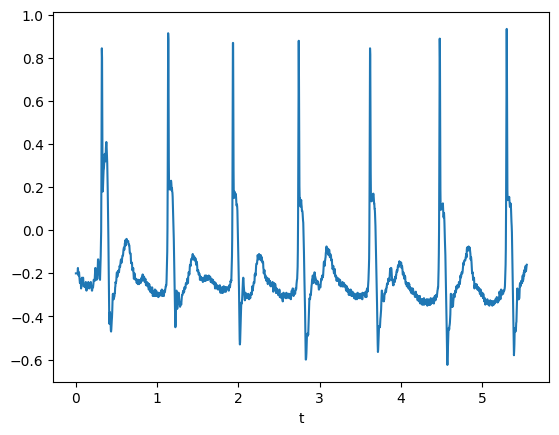

In [18]:
signal = pd.read_csv("data/102_V5.dat", header=None)
signal = signal.to_numpy().flatten()

print(f"{signal.shape=}")

fs = 360

plt.plot(np.arange(2000) / fs, signal[:2000])
plt.xlabel("t")
plt.show()

In [19]:
with open("data/102_attr.dat") as f:
    content = f.read()
    lines = content.split("\n")
    import re

    numbers = [int(n) for n in re.findall(r"\d+", content)]

GT_PEAKS = np.array(numbers)
GT_PEAKS.shape

(2187,)

In [20]:
# fragment = signal[:2000]
fragment = signal
gt_fragment_peaks = GT_PEAKS[GT_PEAKS < fragment.shape[0]]

In [21]:
signal_peaks = detect_r_peaks(fragment, fs)

THRESHOLD_I1=0.000325, THRESHOLD_I2=0.0001625
MIN_DISTANCE_INDICES=72.0


In [22]:
evaluate_detections(signal_peaks, gt_fragment_peaks, fs)

tolerance_samples=10


{'TP': 2121,
 'FP': 64,
 'FN': 66,
 'agreement': 0.9422478898267437,
 'MAE_ms': 2.069254544502069,
 'SD_ms': 1.5429723173853331,
 'errors_ms': array([-2.77777778, -2.77777778, -2.77777778, ..., -2.77777778,
        -2.77777778, -2.77777778]),
 'matched_gt': array([   410,    697,    989, ..., 649244, 649553, 649852]),
 'matched_det': array([   409,    696,    988, ..., 649243, 649552, 649851])}

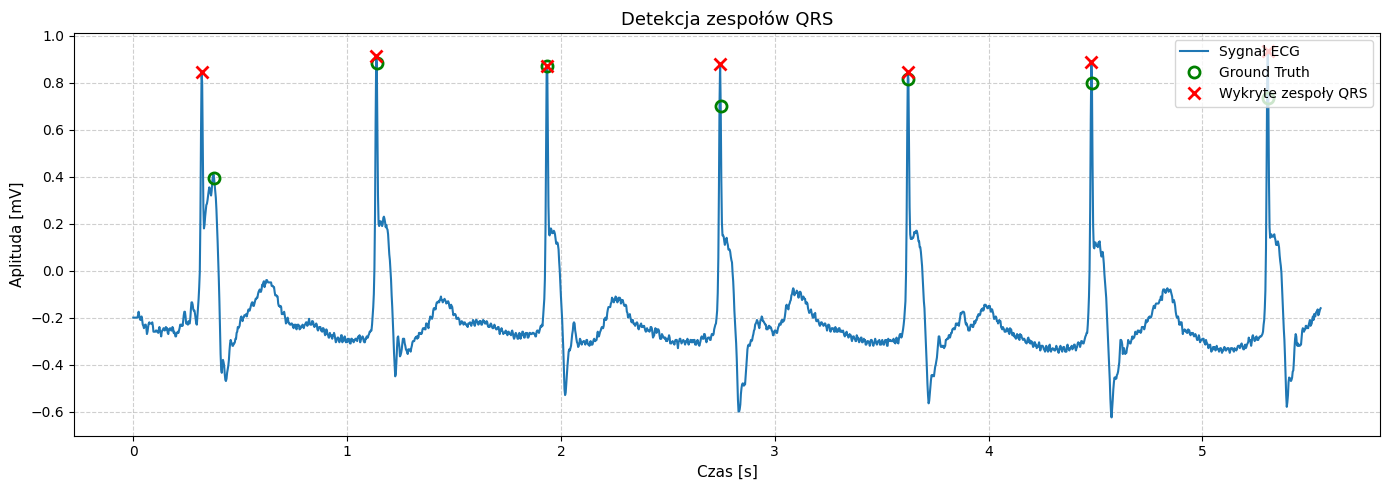

In [23]:
import matplotlib.pyplot as plt
import numpy as np

start_sample = 0
end_sample = 2000

ecg_fragment = signal[start_sample:end_sample]
time_axis = (
        np.arange(start_sample, end_sample) / fs
)

detected_in_fragment = signal_peaks[(signal_peaks >= start_sample) & (signal_peaks < end_sample)]
gt_in_fragment = gt_fragment_peaks[(gt_fragment_peaks >= start_sample) & (gt_fragment_peaks < end_sample)]

plt.figure(figsize=(14, 5))

plt.plot(time_axis, ecg_fragment, label="Sygnał ECG")

plt.plot(
    gt_in_fragment / fs,
    signal[gt_in_fragment],
    "go",
    markersize=8,
    markerfacecolor="none",
    markeredgewidth=2,
    label="Ground Truth",
)

plt.plot(
    detected_in_fragment / fs,
    signal[detected_in_fragment],
    "rx",
    markersize=9,
    markeredgewidth=2,
    label="Wykryte zespoły QRS",
)

plt.title("Detekcja zespołów QRS", fontsize=13)
plt.xlabel("Czas [s]", fontsize=11)
plt.ylabel("Aplituda [mV]", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()

plt.show()